# Train 7.3M ELT Supervised Model (Kaggle T4x2)

This notebook pulls the `elt-supervised-7.3m` repository and begins training using the dual T4 GPUs available on Kaggle. It is pre-configured with optimizations for T4 hardware (e.g. `use_bfloat16: False` to avoid slow emulation).

**Persistent cache:** Checkpoints and latent files are backed up to `/kaggle/working/elt_cache/` so they survive `git clone` re-runs. If you attach a previous notebook output as a Kaggle input dataset, it will also restore from `/kaggle/input/`.

In [ ]:
!pip install torch torchvision diffusers accelerate tqdm pillow kagglehub

In [3]:
!cp /kaggle/input/datasets/wittyheisen/elt-sr-best /kaggle/working/elt-supervised-7.3m/checkpoints

cp: -r not specified; omitting directory '/kaggle/input/datasets/wittyheisen/elt-sr-best'


In [4]:
!cp /kaggle/input/datasets/wittyheisen/elt-sr-best /kaggle/working/elt_cache/checkpoints

cp: -r not specified; omitting directory '/kaggle/input/datasets/wittyheisen/elt-sr-best'


In [4]:
import os, shutil, glob

if os.path.exists('/kaggle/working'):
    os.chdir('/kaggle/working')

CACHE_DIR = '/kaggle/working/elt_cache'
REPO_DIR  = '/kaggle/working/elt-supervised-7.3m'

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(f'{CACHE_DIR}/checkpoints', exist_ok=True)

# ── STEP 1: Backup checkpoints & latents BEFORE deleting repo ──
if os.path.exists(f'{REPO_DIR}/checkpoints'):
    for f in glob.glob(f'{REPO_DIR}/checkpoints/*.pt'):
        dst = f'{CACHE_DIR}/checkpoints/{os.path.basename(f)}'
        print(f'  Backing up {os.path.basename(f)} -> cache')
        shutil.copy2(f, dst)

if os.path.exists(f'{REPO_DIR}/latents_ffhq_128.pt'):
    print('  Backing up latents_ffhq_128.pt -> cache')
    shutil.copy2(f'{REPO_DIR}/latents_ffhq_128.pt', f'{CACHE_DIR}/latents_ffhq_128.pt')

# ── STEP 2: Fresh clone ──
!rm -rf elt-supervised-7.3m
!git clone https://github.com/ParthBrijpuria/elt-supervised-7.3m.git
%cd elt-supervised-7.3m

# ── STEP 3: Restore from cache (same session) ──
os.makedirs('checkpoints', exist_ok=True)
for f in glob.glob(f'{CACHE_DIR}/checkpoints/*.pt'):
    dst = f'checkpoints/{os.path.basename(f)}'
    if not os.path.exists(dst):
        print(f'  Restoring {os.path.basename(f)} from cache')
        shutil.copy2(f, dst)

if os.path.exists(f'{CACHE_DIR}/latents_ffhq_128.pt') and not os.path.exists('latents_ffhq_128.pt'):
    print('  Restoring latents_ffhq_128.pt from cache')
    shutil.copy2(f'{CACHE_DIR}/latents_ffhq_128.pt', 'latents_ffhq_128.pt')

# ── STEP 4: Restore from /kaggle/input/ (cross-session, if attached as dataset) ──
for input_dir in glob.glob('/kaggle/input/*/checkpoints'):
    for f in glob.glob(f'{input_dir}/*.pt'):
        dst = f'checkpoints/{os.path.basename(f)}'
        if not os.path.exists(dst):
            print(f'  Restoring {os.path.basename(f)} from /kaggle/input/')
            shutil.copy2(f, dst)

for input_dir in glob.glob('/kaggle/input/*'):
    src = f'{input_dir}/latents_ffhq_128.pt'
    if os.path.exists(src) and not os.path.exists('latents_ffhq_128.pt'):
        print('  Restoring latents_ffhq_128.pt from /kaggle/input/')
        shutil.copy2(src, 'latents_ffhq_128.pt')

# ── Summary ──
existing_ckpts = glob.glob('checkpoints/*.pt')
has_latents = os.path.exists('latents_ffhq_128.pt')
print(f'\n✅ Ready! Checkpoints found: {len(existing_ckpts)}, Latent file: {"YES" if has_latents else "NO"}')

Cloning into 'elt-supervised-7.3m'...
remote: Enumerating objects: 134, done.
remote: Counting objects: 100% (134/134), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 134 (delta 73), reused 98 (delta 37), pack-reused 0 (from 0)
Receiving objects: 100% (134/134), 129.96 KiB | 9.28 MiB/s, done.
Resolving deltas: 100% (73/73), done.
/kaggle/working/elt-supervised-7.3m

✅ Ready! Checkpoints found: 0, Latent file: NO


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("greatgamedota/ffhq-face-data-set")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/greatgamedota/ffhq-face-data-set


## Step 1: Pre-encode all images through the VAE (runs ONCE, ~3 min)

This encodes all 70,000 FFHQ images into VAE latent tensors and saves them to a `.pt` file.
Training then loads directly from RAM — **no VAE, no PNG decoding, no disk I/O** during training.

**Automatically skipped if `latents_ffhq_128.pt` already exists** (restored from cache).

In [5]:
import os
if not os.path.exists('latents_ffhq_128.pt'):
    !python preprocess_latents.py --train_dir $path --output latents_ffhq_128.pt --batch_size 128
    # Backup to cache immediately
    import shutil
    shutil.copy2('latents_ffhq_128.pt', '/kaggle/working/elt_cache/latents_ffhq_128.pt')
    print('Backed up latents to cache.')
else:
    print('latents_ffhq_128.pt already exists, skipping preprocessing.')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading VAE...
Loading VAE from stabilityai/sd-vae-ft-mse...
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
config.json: 100%|█████████████████████████████| 547/547 [00:00<00:00, 2.37MB/s]
diffusion_pytorch_model.safetensors: 100%|████| 335M/335M [00:03<00:00, 110MB/s]
SRDataset: Found 70000 images in /kaggle/input/datasets/greatgamedota/ffhq-face-data-set
Encoding 70000 images through VAE (batch_size=128)...
Encoding latents: 100%|███████████████████████| 547/547 [02:40<00:00,  3.4

## Step 2: Train with pre-encoded latents on dual T4 GPUs

Training auto-resumes from the latest checkpoint if one exists.

In [9]:
import shutil, os, glob

# Find elt_sr_best.pt anywhere in /kaggle/input/
for f in glob.glob("/kaggle/input/**/elt_sr_best.pt", recursive=True):
    os.makedirs("checkpoints", exist_ok=True)
    shutil.copy2(f, "checkpoints/elt_sr_best.pt")
    print(f"Copied {f} -> checkpoints/elt_sr_best.pt")
    break
else:
    print("elt_sr_best.pt not found in /kaggle/input/. Upload it as a Kaggle dataset first.")


Copied /kaggle/input/datasets/wittyheisen/elt-sr-best/elt_sr_best.pt -> checkpoints/elt_sr_best.pt


In [2]:
import glob, torch

print("--- Searching for Checkpoints ---")
all_files = glob.glob("/kaggle/**/*.pt", recursive=True)
found = False

for f in all_files:
    if "elt_sr_" in f or "best" in f:
        try:
            ckpt = torch.load(f, map_location="cpu")
            ep = ckpt.get("epoch", "Unknown")
            print(f"File: {f}")
            print(f"  -> Saved at Epoch: {ep}")
            found = True
        except:
            pass

if not found:
    print("No checkpoints found anywhere!")


--- Searching for Checkpoints ---
File: /kaggle/input/datasets/wittyheisen/elt-sr-best/elt_sr_best.pt
  -> Saved at Epoch: 434


In [ ]:
!accelerate launch --num_processes 2 run_train.py \
    --train_dir $path \
    --img_size 64 \
    --scale 4 \
    --output_dir checkpoints_64 \
    --epochs 1000 \
    --batch_size 64


The following values were not passed to `accelerate launch` and had defaults used instead:
		More than one GPU was found, enabling multi-GPU training.
		If this was unintended please pass in `--num_processes=1`.
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.


## Step 3: Backup checkpoints to cache (run after training or before stopping)

This ensures your checkpoints survive the next `git clone`.

In [28]:
import shutil, glob, os
os.makedirs('/kaggle/working/elt_cache/checkpoints', exist_ok=True)
for f in glob.glob('checkpoints/*.pt'):
    shutil.copy2(f, f'/kaggle/working/elt_cache/checkpoints/{os.path.basename(f)}')
    print(f'Backed up {os.path.basename(f)}')
print('Done! Checkpoints are safe in /kaggle/working/elt_cache/')

Backed up elt_sr_best.pt
Done! Checkpoints are safe in /kaggle/working/elt_cache/


In [20]:
from IPython.display import display, Image
import glob

for img in sorted(glob.glob("checkpoints/samples/*.png")):
    print(img)
    display(Image(filename=img, width=250))


In [7]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from pathlib import Path
import random

# Import our custom modules
from elt_sr.config import ELTConfig
from elt_sr.model import create_elt_sr
from elt_sr.vae import VAEWrapper
from elt_sr.diffusion import shifted_cosine_schedule, ddim_sample_loop
from elt_sr.data import PreencodedLatentDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running inference on {device}...")

# 1. Load Model & VAE
config = ELTConfig()
model = create_elt_sr(config).to(device)
vae = VAEWrapper(device=device)

ckpt_path = "checkpoints/elt_sr_best.pt"
if not Path(ckpt_path).exists():
    print(f"Error: {ckpt_path} not found!")
else:
    ckpt = torch.load(ckpt_path, map_location=device)
    
    # --- FIX: Load EMA weights instead of raw training weights! ---
    if "ema_state_dict" in ckpt:
        m_state = {k.replace("_orig_mod.", ""): v for k, v in ckpt["ema_state_dict"].items()}
        print("Loaded EMA model weights successfully! (Expect much better quality)")
    else:
        m_state = {k.replace("_orig_mod.", ""): v for k, v in ckpt["model_state_dict"].items()}
        print("Warning: EMA weights not found, using raw model weights.")
        
    model.load_state_dict(m_state)
    model.eval()

    # 2. Get Data (using your cached latents for speed)
    latent_path = "/kaggle/working/elt_cache/latents_ffhq_128.pt"
    dataset = PreencodedLatentDataset(latent_path)
    
    # Pick 10 random indices
    indices = random.sample(range(len(dataset)), 10)
    
    z_bases = []
    z_hqs_real = []
    for idx in indices:
        sample = dataset[idx]
        z_bases.append(sample["z_base"])
        z_hqs_real.append(sample["z_hq"])
        
    z_base = torch.stack(z_bases).to(device)
    
    # 3. Run Inference
    print("Running diffusion generation...")
    T = config.num_timesteps
    schedule = shifted_cosine_schedule(num_timesteps=T, shift=config.schedule_shift, cosine_s=config.schedule_cosine_s)
    
    with torch.no_grad():
        # Denoise using DDIM
        z_pred_hq = ddim_sample_loop(
            model, z_base, schedule, 
            ddim_steps=50, 
            num_loops=config.max_loops, 
            device=device, 
            verbose=False
        )
        
        # Decode back to pixel space
        img_base = vae.decode(z_base).cpu()         # Before (Bicubic LQ)
        img_pred = vae.decode(z_pred_hq).cpu()      # After (Model HQ)

    # 4. Visualization
    fig, axes = plt.subplots(10, 2, figsize=(2,10))
    fig.suptitle("ELT-SR: Before (32x32 Bicubic) vs After (Model)", fontsize=16, y=0.92)
    
    for i in range(10):
        # Before
        axes[i, 0].imshow(img_base[i].permute(1, 2, 0).clamp(0, 1).numpy())
        axes[i, 0].axis("off")
        if i == 0: axes[i, 0].set_title("Before (LQ)")
            
        # After
        axes[i, 1].imshow(img_pred[i].permute(1, 2, 0).clamp(0, 1).numpy())
        axes[i, 1].axis("off")
        if i == 0: axes[i, 1].set_title("After (Generated HQ)")
            
    plt.tight_layout()
    plt.show()


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Running inference on cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading VAE from stabilityai/sd-vae-ft-mse...
Error: checkpoints/elt_sr_best.pt not found!


In [32]:
%ls /kaggle/working/elt-supervised-7.3m/checkpoints_64/

config.json     elt_sr_ep150.pt  elt_sr_ep250.pt  elt_sr_ep50.pt    samples/
elt_sr_best.pt  elt_sr_ep200.pt  elt_sr_ep300.pt  elt_sr_latest.pt


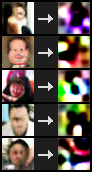

In [31]:
from IPython.display import Image, display

# Path to your target image
img_path = '/kaggle/working/elt-supervised-7.3m/checkpoints_64/samples/ep300_sample.png'

display(Image(filename=img_path))

In [17]:
import shutil, os, glob

# Search for the file anywhere in the input folder
found_files = glob.glob("/kaggle/input/**/elt_sr_best.pt", recursive=True)

if found_files:
    target_dir = "/kaggle/working/elt-supervised-7.3m/checkpoints"
    os.makedirs(target_dir, exist_ok=True)
    
    source_file = found_files[0]
    dest_file = f"{target_dir}/elt_sr_best.pt"
    
    shutil.copy2(source_file, dest_file)
    print(f"Success! Copied from {source_file} to {dest_file}")
else:
    print("Error: elt_sr_best.pt not found anywhere in /kaggle/input/.")


Success! Copied from /kaggle/input/datasets/wittyheisen/elt-sr-best/elt_sr_best.pt to /kaggle/working/elt-supervised-7.3m/checkpoints/elt_sr_best.pt


In [33]:
import shutil
shutil.copy2("/kaggle/working/elt-supervised-7.3m/checkpoints_64/elt_sr_best.pt", "/kaggle/working/elt_sr_best.pt")
print("Done! Now click 'Save Version' → the file will appear in your notebook Output tab for download.")


Done! Now click 'Save Version' → the file will appear in your notebook Output tab for download.


In [3]:
!pip install torchmetrics[image]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 2.4 MB/s eta 0:00:00


In [8]:
!python run_eval.py \
    --val_dir /kaggle/input/datasets/greatgamedota/ffhq-face-data-set/thumbnails128x128 \
    --checkpoint checkpoints/elt_sr_best.pt \
    --batch_size 16 \
    --ddim_steps 50 

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Running evaluation on: cuda
Loading VAE from stabilityai/sd-vae-ft-mse...
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading checkpoint from checkpoints/elt_sr_best.pt...
Loaded EMA model weights.
SRDataset: Found 70000 images in /kaggle/input/datasets/greatgamedota/ffhq-face-data-set/thumbnails128x128
Starting evaluation over 4375 batches (Batch Size: 16)
Evaluating: 100%|███| 4375/4375 [46:43<00:00,  1.56it/s, PSNR=13.45, SSIM=0.346]

FINAL EVALUATION RESULTS
Checkpoint: check